# Multimodal BERTopic for Venue Topic Modeling

This notebook extracts semantic topics from venue reviews using BERTopic with:
- Sentence-BERT for text embeddings
- CLIP for image embeddings (optional)
- UMAP for dimensionality reduction
- K-Means/HDBSCAN for clustering
- c-TF-IDF for topic representation

In [1]:
import sys
sys.path.insert(0, '..')

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["MKL_DEBUG_CPU_TYPE"] = "5"
# Force single-threading for math libraries to prevent the "500-minute hang"
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.config import get_config
from src.config.settings import PROCESSED_DATA_DIR, MODEL_DIR
from src.models.bertopic import (
    TextEmbedder,
    ImageEmbedder,
    MultimodalEmbedder,
    VenueTopicExtractor,
    GeoClusterer,
    TimeContextEncoder,
    cluster_venues_by_location,
)
from src.utils.helpers import set_seed

import mkl
mkl.set_num_threads(1)


# Setup
set_seed(42)
config = get_config()

# Output directory
OUTPUT_DIR = MODEL_DIR / 'bertopic'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import os
import sys

# 1. Force these BEFORE any imports
os.environ["NUMBA_DISABLE_INTEL_SVML"] = "1" 
os.environ["MKL_DEBUG_CPU_TYPE"] = "5"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 2. Force Numba to use a stable threading layer
import numba
try:
    numba.config.THREADING_LAYER = 'tbb' 
except:
    numba.config.THREADING_LAYER = 'workqueue'

import torch
import pandas as pd
print(f"Kernel stabilized. GPU: {torch.cuda.get_device_name(0)}")

Kernel stabilized. GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Load Data

In [3]:
# Load reviews
reviews_path = PROCESSED_DATA_DIR / 'train_reviews.parquet'
businesses_path = PROCESSED_DATA_DIR / 'businesses.parquet'

if reviews_path.exists():
    reviews_df = pd.read_parquet(reviews_path)
    print(f"Loaded {len(reviews_df)} reviews")
else:
    raise FileNotFoundError(f"Reviews not found. Run data preparation first.")

if businesses_path.exists():
    businesses_df = pd.read_parquet(businesses_path)
    print(f"Loaded {len(businesses_df)} businesses")
else:
    businesses_df = None
    print("No business data found")

Loaded 4659 reviews
Loaded 5989 businesses


In [4]:
# Check columns
print("Review columns:", reviews_df.columns.tolist())
if businesses_df is not None:
    print("Business columns:", businesses_df.columns.tolist())

Review columns: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date', 'text_length', 'word_count', 'clean_text']
Business columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']


In [5]:
# Determine text column
text_col = 'clean_text' if 'clean_text' in reviews_df.columns else 'text'
print(f"Using text column: {text_col}")

# Sample review
print(f"\nSample review:\n{reviews_df[text_col].iloc[0][:500]}...")

Using text column: clean_text

Sample review:
i had three dogs here because they are that good. i had the dave's style, the western, and the pizza dog. the pizza dog is amazing! i highly recommend dave's dog!...


## 2. Text Embeddings with Sentence-BERT

In [6]:
# Initialize text embedder
text_embedder = TextEmbedder(model_name='all-MiniLM-L6-v2')
print(f"Text embedding dimension: {text_embedder.embedding_dim}")

c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Text embedding dimension: 384


In [7]:
# Test embedding generation
sample_texts = reviews_df[text_col].head(5).tolist()
sample_embeddings = text_embedder.encode(sample_texts)

print(f"Sample embeddings shape: {sample_embeddings.shape}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Sample embeddings shape: (5, 384)


In [8]:
# Group reviews by venue
venue_reviews = reviews_df.groupby('business_id')[text_col].apply(list).to_dict()
venue_ids = list(venue_reviews.keys())

print(f"Number of venues: {len(venue_ids)}")
print(f"Average reviews per venue: {np.mean([len(r) for r in venue_reviews.values()]):.1f}")

Number of venues: 1810
Average reviews per venue: 2.6


In [9]:
# Generate aggregated venue embeddings
# This may take a while for large datasets
venue_texts = [venue_reviews[vid] for vid in venue_ids]

# Limit for demo - use first 1000 venues
MAX_VENUES = 1000
if len(venue_ids) > MAX_VENUES:
    print(f"Limiting to {MAX_VENUES} venues for demo")
    venue_ids = venue_ids[:MAX_VENUES]
    venue_texts = venue_texts[:MAX_VENUES]

venue_embeddings = text_embedder.encode_aggregated(
    venue_texts,
    aggregation='mean',
    batch_size=32,
)

print(f"Venue embeddings shape: {venue_embeddings.shape}")

Limiting to 1000 venues for demo


Encoding text groups: 100%|██████████| 1000/1000 [00:07<00:00, 128.80it/s]

Venue embeddings shape: (1000, 384)


## 3. Topic Extraction with BERTopic

In [10]:
# Configure topic extractor
config.bertopic.kmeans_n_clusters = 20  # Number of topics
config.bertopic.umap_n_components = 5

# Create extractor
extractor = VenueTopicExtractor(config=config.bertopic)
extractor.build_model(use_kmeans=True)  # Use K-Means for fixed number of topics

In [11]:
# Prepare documents (concatenated reviews per venue)
documents = [" ".join(reviews[:10]) for reviews in venue_texts]  # Limit reviews per venue

print(f"Number of documents: {len(documents)}")
print(f"Average document length: {np.mean([len(d.split()) for d in documents]):.0f} words")

Number of documents: 1000
Average document length: 233 words


In [13]:
# Fit topic model
topics, probs = extractor.fit(documents, embeddings=venue_embeddings)

print(f"\nTopics assigned: {len(topics)}")
print(f"Unique topics: {len(set(topics))}")

2026-02-01 10:32:56,753 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-01 10:33:05,059 - BERTopic - Dimensionality - Completed ✓
2026-02-01 10:33:05,059 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-01 10:33:05,189 - BERTopic - Cluster - Completed ✓
2026-02-01 10:33:05,195 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-01 10:33:06,544 - BERTopic - Representation - Completed ✓



Topics assigned: 1000
Unique topics: 20


In [14]:
# Get topic information
topic_info = extractor.get_topic_info()

print(f"\nExtracted {len(topic_info)} topics:\n")
for info in topic_info[:15]:
    print(f"Topic {info.topic_id}: {info.name}")
    print(f"  Count: {info.count} venues")
    print(f"  Keywords: {', '.join(info.representation[:5])}")
    print()


Extracted 20 topics:

Topic 0: 0_shop_mall_store_prices
  Count: 85 venues
  Keywords: shop, mall, store, prices, items

Topic 1: 1_beers_drinks_cocktails_beer
  Count: 81 venues
  Keywords: beers, drinks, cocktails, beer, cocktail

Topic 2: 2_meal_lunch_breakfast_food
  Count: 77 venues
  Keywords: meal, lunch, breakfast, food, steak

Topic 3: 3_restaurant_waiter_steak_waitress
  Count: 69 venues
  Keywords: restaurant, waiter, steak, waitress, serve

Topic 4: 4_dining_restaurant_restaurants_meal
  Count: 68 venues
  Keywords: dining, restaurant, restaurants, meal, dishes

Topic 5: 5_restaurant_shrimp_meal_dinner
  Count: 57 venues
  Keywords: restaurant, shrimp, meal, dinner, bbq

Topic 6: 6_tacos_taco_restaurant_tasty
  Count: 54 venues
  Keywords: tacos, taco, restaurant, tasty, meal

Topic 7: 7_restaurant_dining_dinner_meal
  Count: 51 venues
  Keywords: restaurant, dining, dinner, meal, waiter

Topic 8: 8_burgers_burger_bbq_beers
  Count: 50 venues
  Keywords: burgers, burger, b

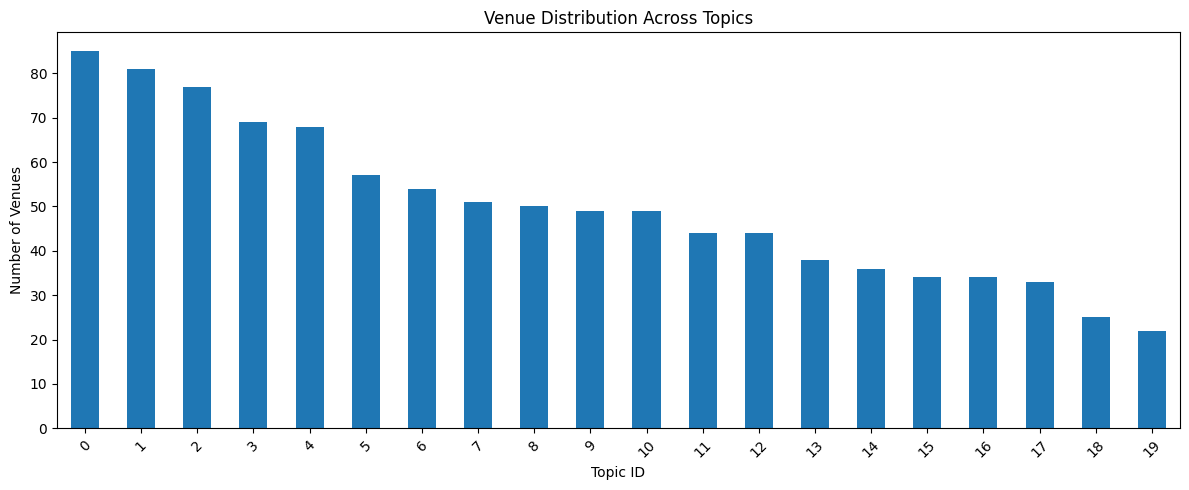

In [15]:
# Topic distribution
topic_counts = pd.Series(topics).value_counts().sort_index()

plt.figure(figsize=(12, 5))
topic_counts[topic_counts.index >= 0].plot(kind='bar')
plt.xlabel('Topic ID')
plt.ylabel('Number of Venues')
plt.title('Venue Distribution Across Topics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Topic Visualizations

In [16]:
# Interactive topic visualization
try:
    fig = extractor.visualize_topics()
    fig.show()
except Exception as e:
    print(f"Visualization failed: {e}")

In [17]:
# Topic barchart
try:
    fig = extractor.visualize_barchart(top_n_topics=10)
    fig.show()
except Exception as e:
    print(f"Barchart failed: {e}")

## 5. Geographic Clustering

In [18]:
# Check if we have location data
if businesses_df is not None and 'latitude' in businesses_df.columns:
    print("Location data available")
    print(f"Latitude range: {businesses_df['latitude'].min():.2f} to {businesses_df['latitude'].max():.2f}")
    print(f"Longitude range: {businesses_df['longitude'].min():.2f} to {businesses_df['longitude'].max():.2f}")
else:
    print("No location data available")

Location data available
Latitude range: 27.58 to 53.64
Longitude range: -120.00 to -74.66


In [19]:
if businesses_df is not None and 'latitude' in businesses_df.columns:
    # Cluster venues by location
    venue_regions, geo_clusterer = cluster_venues_by_location(
        businesses_df,
        lat_col='latitude',
        lon_col='longitude',
        id_col='business_id',
        min_cluster_size=10,
    )
    
    print(f"\nFound {len(geo_clusterer.regions)} geographic regions:\n")
    for region in geo_clusterer.regions[:10]:
        print(f"{region.name}:")
        print(f"  Venues: {region.venue_count}")
        print(f"  Center: ({region.center_lat:.4f}, {region.center_lon:.4f})")
        print(f"  Radius: {region.radius_km:.2f} km")
        print()


Found 156 geographic regions:

Region_0_NorthWest:
  Venues: 346
  Center: (32.2439, -110.9377)
  Radius: 38.01 km

Region_1_NorthWest:
  Venues: 20
  Center: (53.5421, -113.3080)
  Radius: 4.05 km

Region_2_NorthWest:
  Venues: 272
  Center: (39.5125, -119.7902)
  Radius: 25.90 km

Region_3_NorthWest:
  Venues: 17
  Center: (34.4022, -119.5325)
  Radius: 3.31 km

Region_4_NorthWest:
  Venues: 10
  Center: (43.6909, -116.3603)
  Radius: 3.54 km

Region_5_NorthWest:
  Venues: 11
  Center: (53.6304, -113.6184)
  Radius: 3.06 km

Region_6_NorthWest:
  Venues: 12
  Center: (34.4125, -119.8531)
  Radius: 1.18 km

Region_7_NorthWest:
  Venues: 14
  Center: (38.8989, -90.1572)
  Radius: 8.54 km

Region_8_NorthWest:
  Venues: 12
  Center: (34.4307, -119.8731)
  Radius: 1.50 km

Region_9_NorthWest:
  Venues: 17
  Center: (34.4361, -119.8233)
  Radius: 2.32 km



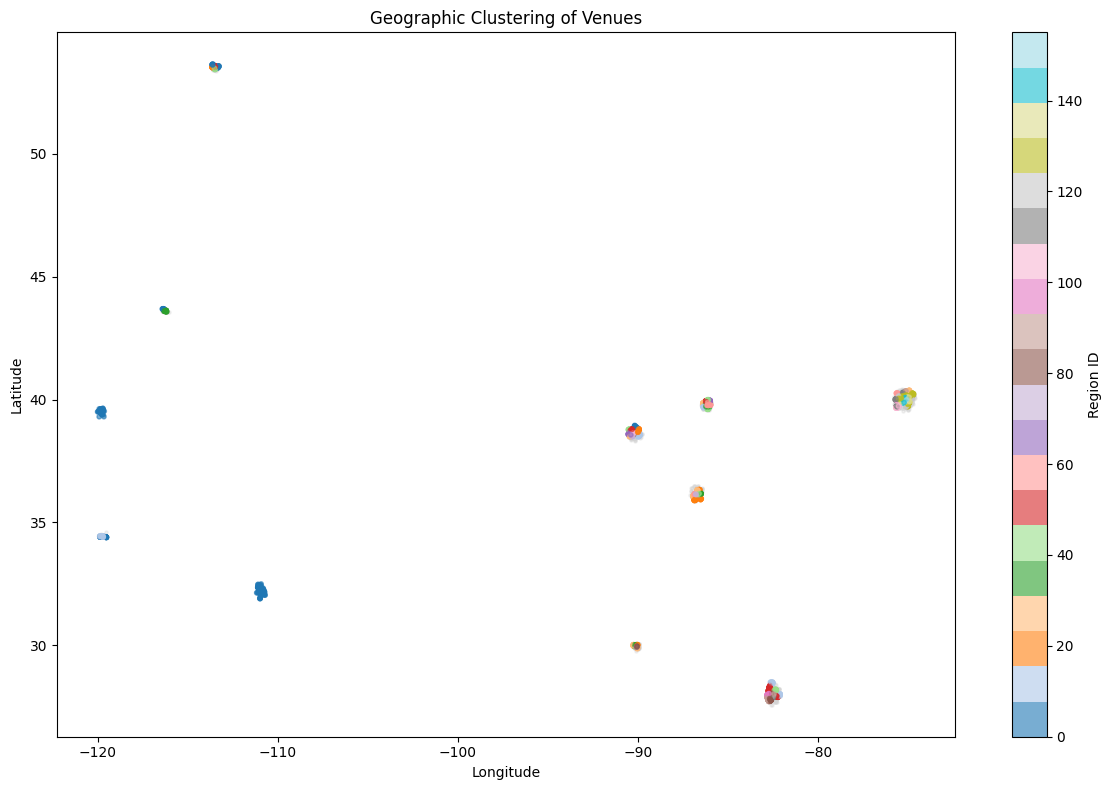

In [20]:
# Visualize geographic clusters
if businesses_df is not None and 'latitude' in businesses_df.columns:
    # Merge with cluster labels
    plot_df = businesses_df.merge(
        venue_regions[['venue_id', 'region_id', 'region_name']],
        left_on='business_id',
        right_on='venue_id',
        how='left'
    )
    
    plt.figure(figsize=(12, 8))
    
    # Plot outliers in gray
    outliers = plot_df[plot_df['region_id'] == -1]
    plt.scatter(
        outliers['longitude'], 
        outliers['latitude'],
        c='lightgray',
        s=5,
        alpha=0.3,
        label='Outliers'
    )
    
    # Plot clusters
    clustered = plot_df[plot_df['region_id'] >= 0]
    scatter = plt.scatter(
        clustered['longitude'],
        clustered['latitude'],
        c=clustered['region_id'],
        cmap='tab20',
        s=10,
        alpha=0.6
    )
    
    plt.colorbar(scatter, label='Region ID')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Geographic Clustering of Venues')
    plt.tight_layout()
    plt.show()

## 6. Context Encoding (Time & Weather)

In [21]:
# Time context encoder
time_encoder = TimeContextEncoder(embedding_dim=16)

# Example: encode different time contexts
hours = np.array([9, 14, 19, 23])  # Morning, afternoon, evening, night
months = np.array([3, 7, 10, 1])   # Spring, summer, fall, winter
is_weekend = np.array([False, True, False, True])

time_embeddings = time_encoder.encode(hours, months, is_weekend)

print("Time context embeddings:")
for i, (h, m, w) in enumerate(zip(hours, months, is_weekend)):
    day_type = "weekend" if w else "weekday"
    print(f"  {h}:00, Month {m}, {day_type}: shape {time_embeddings[i].shape}")

Time context embeddings:
  9:00, Month 3, weekday: shape (16,)
  14:00, Month 7, weekend: shape (16,)
  19:00, Month 10, weekday: shape (16,)
  23:00, Month 1, weekend: shape (16,)


## 7. Create Venue-Topic DataFrame

In [24]:
# Create venue topics DataFrame with a safety check for probs
venue_topics_df = pd.DataFrame({
    'venue_id': venue_ids,
    'topic': topics,
    'topic_prob': [p.max() if isinstance(p, np.ndarray) else p for p in probs] if probs is not None else [1.0] * len(topics),
})

# Add topic names
# Ensure topic_info is actually populated before mapping
topic_names = {t.topic_id: t.name for t in topic_info}
venue_topics_df['topic_name'] = venue_topics_df['topic'].map(topic_names)

print(venue_topics_df.head(10))

                 venue_id  topic  topic_prob  \
0  --ZVrH2X2QXBFdCilbirsw     15         1.0   
1  -02xFuruu85XmDn2xiynJw      0         1.0   
2  -1ueCbvIpUPi8KT95ETTKw      9         1.0   
3  -2ke_JDOpgTZWqirMFjZcw      1         1.0   
4  -3AooxIkg38UyUdlz5oXdw      5         1.0   
5  -7GDqSUaXrpC8Ql7nDBxWA     17         1.0   
6  -7GjicSH_rM8JeZGCXGcUg      1         1.0   
7  -BhSR6dAry5-2x3ndjX_9w     19         1.0   
8  -Fka99c-tJ-epWYNIobqyQ     10         1.0   
9  -HUDQ5eek6Edz3zuNrE4jw      9         1.0   

                                topic_name  
0         15_customer_return_returned_rude  
1                 0_shop_mall_store_prices  
2        9_hotel_restaurants_room_downtown  
3            1_beers_drinks_cocktails_beer  
4          5_restaurant_shrimp_meal_dinner  
5  17_restaurants_restaurant_salmon_shrimp  
6            1_beers_drinks_cocktails_beer  
7           19_hair_cut_recommend_fabulous  
8          10_pizza_steak_cheese_delicious  
9        9_hotel_rest

In [25]:
# Merge with geographic regions if available
if 'venue_regions' in dir():
    venue_topics_df = venue_topics_df.merge(
        venue_regions[['venue_id', 'region_id', 'region_name']],
        on='venue_id',
        how='left'
    )
    print("Added geographic regions")
    print(venue_topics_df.head())

Added geographic regions
                 venue_id  topic  topic_prob  \
0  --ZVrH2X2QXBFdCilbirsw     15         1.0   
1  -02xFuruu85XmDn2xiynJw      0         1.0   
2  -1ueCbvIpUPi8KT95ETTKw      9         1.0   
3  -2ke_JDOpgTZWqirMFjZcw      1         1.0   
4  -3AooxIkg38UyUdlz5oXdw      5         1.0   

                          topic_name  region_id           region_name  
0   15_customer_return_returned_rude        141  Region_141_NorthWest  
1           0_shop_mall_store_prices          0    Region_0_NorthWest  
2  9_hotel_restaurants_room_downtown          2    Region_2_NorthWest  
3      1_beers_drinks_cocktails_beer         38   Region_38_NorthWest  
4    5_restaurant_shrimp_meal_dinner         13   Region_13_NorthWest  


## 8. Save Results

In [26]:
# Save topic model
extractor.save(OUTPUT_DIR / 'topic_model')
print(f"Saved topic model to {OUTPUT_DIR / 'topic_model'}")

# Save venue topics
venue_topics_df.to_parquet(OUTPUT_DIR / 'venue_topics.parquet', index=False)
print(f"Saved venue topics to {OUTPUT_DIR / 'venue_topics.parquet'}")

# Save venue embeddings
np.save(OUTPUT_DIR / 'venue_embeddings.npy', venue_embeddings)
print(f"Saved venue embeddings to {OUTPUT_DIR / 'venue_embeddings.npy'}")

# Save topic info
topic_info_df = pd.DataFrame([
    {
        'topic_id': t.topic_id,
        'name': t.name,
        'count': t.count,
        'keywords': ', '.join(t.representation[:10]),
    }
    for t in topic_info
])
topic_info_df.to_csv(OUTPUT_DIR / 'topic_info.csv', index=False)
print(f"Saved topic info to {OUTPUT_DIR / 'topic_info.csv'}")

2026-02-01 10:36:04,943 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved topic model to c:\Users\ewenl\draft-koko\notebooks\..\models\bertopic\topic_model
Saved venue topics to c:\Users\ewenl\draft-koko\notebooks\..\models\bertopic\venue_topics.parquet
Saved venue embeddings to c:\Users\ewenl\draft-koko\notebooks\..\models\bertopic\venue_embeddings.npy
Saved topic info to c:\Users\ewenl\draft-koko\notebooks\..\models\bertopic\topic_info.csv


In [27]:
# Save visualizations
try:
    extractor.visualize_topics(OUTPUT_DIR / 'topic_visualization.html')
    extractor.visualize_barchart(top_n_topics=20, output_path=OUTPUT_DIR / 'topic_barchart.html')
    print("Saved visualizations")
except Exception as e:
    print(f"Failed to save visualizations: {e}")

Saved visualizations


## Summary

We've extracted:
1. **Venue Topics**: Semantic themes from review text
2. **Geographic Regions**: Location-based clusters
3. **Context Encoders**: Time and weather embeddings

These will be used in Phase 4 to build the heterogeneous graph:
- **User nodes**: MBTI embeddings (from Phase 2)
- **Venue nodes**: Topic embeddings (from this phase)
- **Context nodes**: Region, time, weather embeddings